In [ ]:
import os
import shutil
import glob
from google.colab import drive

# --- A. GÜVENLİ DRIVE BAĞLANTISI VE ZİPTEN ÇIKARMA ---

# 1. Drive bağlı mı diye kontrol et, değilse bağla
if not os.path.exists('/content/drive'):
    print("Google Drive bağlanıyor...")
    drive.mount('/content/drive')
else:
    print(" Google Drive zaten bağlı.")

# 2. Zip Yolu ve Hedef
zip_path = "/content/drive/MyDrive/DATASET/acne_1024.zip" # Drive yolunuz
raw_root = '/content/raw_data_root' # Geçici açılma yeri

# 3. Temizle ve Aç
if os.path.exists(raw_root):
    shutil.rmtree(raw_root)

print(f"Zip dosyası açılıyor: {zip_path}")

try:
    !unzip -q "{zip_path}" -d "{raw_root}"

    # 'ls' çıktınıza göre resimler bu alt klasördeydi:
    source_images_dir = os.path.join(raw_root, 'acne_1024')

    # --- B. 2 SINIFLI (BINARY) YAPIYI OLUŞTURMA ---
    binary_dataset_dir = '/content/binary_dataset' # Düzenlenmiş hali
    if os.path.exists(binary_dataset_dir): shutil.rmtree(binary_dataset_dir)

    # Hedef klasörleri yarat (0_akne_yok, 1_akne_var)
    os.makedirs(os.path.join(binary_dataset_dir, '0_akne_yok'), exist_ok=True)
    os.makedirs(os.path.join(binary_dataset_dir, '1_akne_var'), exist_ok=True)

    print("Veriler 2 sınıfa (Var/Yok) dönüştürülüyor...")

    # 1. 'acne0' -> '0_akne_yok' içine
    source_acne0 = os.path.join(source_images_dir, 'acne0_1024')
    if os.path.exists(source_acne0):
        for img in glob.glob(os.path.join(source_acne0, '*.*')):
            shutil.copy(img, os.path.join(binary_dataset_dir, '0_akne_yok'))
        print("- Sınıf 0 (Temiz) kopyalandı.")

    # 2. 'acne1', 'acne2', 'acne3' -> '1_akne_var' içine (BİRLEŞTİRME)
    acne_vars = ['acne1_1024', 'acne2_1024', 'acne3_1024']
    for cls in acne_vars:
        src = os.path.join(source_images_dir, cls)
        dst = os.path.join(binary_dataset_dir, '1_akne_var')
        if os.path.exists(src):
            for img in glob.glob(os.path.join(src, '*.*')):
                shutil.copy(img, dst)
            print(f"- {cls} sınıfı '1_akne_var' içine eklendi.")

    # --- C. VERİYİ BÖLME (SPLITFOLDERS) ---
    print("\nVeri seti train/val/test olarak bölünüyor...")
    !pip install -q split-folders
    import splitfolders

    final_dataset_dir = '/content/binary_processed_dataset'
    if os.path.exists(final_dataset_dir): shutil.rmtree(final_dataset_dir)

    splitfolders.ratio(binary_dataset_dir,
                       output=final_dataset_dir,
                       seed=1337,
                       ratio=(.7, .2, .1),
                       group_prefix=None)

    print("\n Veri hazırlığı tamamlandı!")
    print(f"Klasörler: {final_dataset_dir}")
    !ls {final_dataset_dir}/train

except Exception as e:
    print(f"\n BİR HATA OLUŞTU: {e}")
    print("Lütfen Drive yolunuzun doğru olduğundan emin olun.")

 Google Drive zaten bağlı.
Zip dosyası açılıyor: /content/drive/MyDrive/DATASET/acne_1024.zip
Veriler 2 sınıfa (Var/Yok) dönüştürülüyor...
- Sınıf 0 (Temiz) kopyalandı.
- acne1_1024 sınıfı '1_akne_var' içine eklendi.
- acne2_1024 sınıfı '1_akne_var' içine eklendi.
- acne3_1024 sınıfı '1_akne_var' içine eklendi.

Veri seti train/val/test olarak bölünüyor...


Copying files: 1378 files [00:00, 4526.70 files/s]


 Veri hazırlığı tamamlandı!
Klasörler: /content/binary_processed_dataset
0_akne_yok  1_akne_var


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# --- AYARLAR ---
IMG_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = '/content/binary_processed_dataset'

print("--- Eğitim Başlıyor ---")

# 1. Veri Yükleyicileri (Binary Mode)
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='binary'
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='binary', shuffle=False
)

class_names = train_ds.class_names
print(f"Sınıflar: {class_names}") # ['0_akne_yok', '1_akne_var'] olmalı

--- Eğitim Başlıyor ---
Found 963 files belonging to 2 classes.
Found 275 files belonging to 2 classes.
Found 139 files belonging to 2 classes.
Sınıflar: ['0_akne_yok', '1_akne_var']


In [ ]:
# 2. Sınıf Ağırlıkları (Dengesizliği çözmek için)
# Klasördeki dosya sayılarını say
train_dir_path = os.path.join(DATA_DIR, 'train')
count_0 = len(os.listdir(os.path.join(train_dir_path, class_names[0])))
count_1 = len(os.listdir(os.path.join(train_dir_path, class_names[1])))
total = count_0 + count_1

# Ağırlık Formülü
weight_0 = (1 / count_0) * (total / 2.0)
weight_1 = (1 / count_1) * (total / 2.0)
class_weights = {0: weight_0, 1: weight_1}

print(f"Sınıf Sayıları -> Yok: {count_0}, Var: {count_1}")
print(f"Hesaplanan Ağırlıklar -> {class_weights}")

Sınıf Sayıları -> Yok: 338, Var: 626
Hesaplanan Ağırlıklar -> {0: 1.4260355029585798, 1: 0.7699680511182109}


In [ ]:
# 3. Augmentation ve Ön İşleme
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.15),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomBrightness(0.2)
])
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Binary etiketleri şekillendirme fonksiyonu
def process_data(x, y):
    return x, tf.expand_dims(y, axis=-1)

# Pipeline oluşturma
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(process_data).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(process_data).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(process_data).prefetch(tf.data.AUTOTUNE)

In [ ]:
# 4. Model Kurulumu (MobileNetV2 - Binary)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False # Önce dondur

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x) # BINARY ÇIKTI
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])

# Erken Durdurma
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

# --- EĞİTİM FAZ 1 ---
print("\nFaz 1 Eğitimi Başlıyor...")
h1 = model.fit(train_ds, epochs=15, validation_data=val_ds,
               class_weight=class_weights, callbacks=[early_stop])

# --- EĞİTİM FAZ 2 (Fine-Tuning) ---
print("\nFaz 2 (Fine-Tuning) Başlıyor...")
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]: layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Düşük hız
              loss='binary_crossentropy', metrics=['accuracy'])

total_epochs = h1.epoch[-1] + 1 + 15
h2 = model.fit(train_ds, epochs=total_epochs, initial_epoch=h1.epoch[-1]+1,
               validation_data=val_ds, class_weight=class_weights, callbacks=[early_stop])

print("\n Eğitim Tamamlandı!")


Faz 1 Eğitimi Başlıyor...
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 47s 874ms/step - accuracy: 0.5054 - loss: 0.7750 - val_accuracy: 0.4800 - val_loss: 0.7048
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 406ms/step - accuracy: 0.6505 - loss: 0.6303 - val_accuracy: 0.5855 - val_loss: 0.6267
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 418ms/step - accuracy: 0.6396 - loss: 0.6068 - val_accuracy: 0.5127 - val_loss: 0.7208
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 429ms/step - accuracy: 0.6375 - loss: 0.6026 - val_accuracy: 0.5709 - val_loss: 0.6679
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 420ms/step - accuracy: 0.6367 - loss: 0.6026 - val_accuracy: 0.6291 - val_loss: 0.6181
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 480ms/step - accuracy: 0.6880 - loss: 0.5611 - val_accuracy: 0.6982 - val_loss: 0.5648
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 419ms/step - accuracy: 0.6489 - loss: 0.5946 - val_accuracy: 0.6836 - val_loss: 0.5786
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 419ms/step - accuracy: 0.718

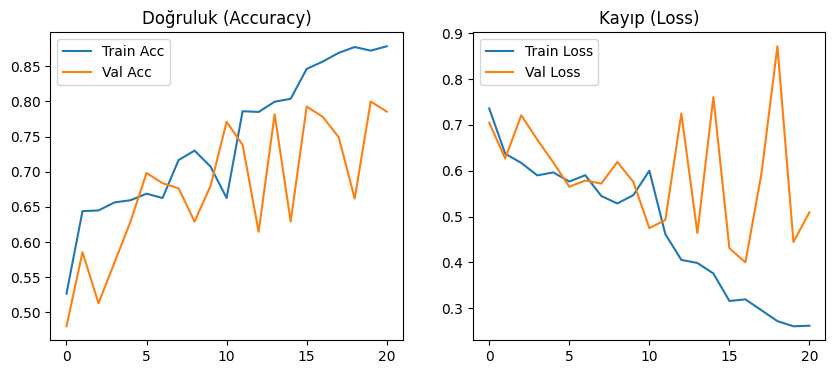

In [ ]:
# Grafik Çiz
acc = h1.history.get('accuracy', []) + h2.history.get('accuracy', [])
val_acc = h1.history.get('val_accuracy', []) + h2.history.get('val_accuracy', [])
loss = h1.history.get('loss', []) + h2.history.get('loss', [])
val_loss = h1.history.get('val_loss', []) + h2.history.get('val_loss', [])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc'); plt.plot(val_acc, label='Val Acc')
plt.legend(); plt.title('Doğruluk (Accuracy)')
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss'); plt.plot(val_loss, label='Val Loss')
plt.legend(); plt.title('Kayıp (Loss)')
plt.show()

Test verisi üzerinde tahmin yapılıyor...
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step

--- SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

  0_akne_yok       0.72      0.63      0.67        49
  1_akne_var       0.81      0.87      0.84        90

    accuracy                           0.78       139
   macro avg       0.77      0.75      0.76       139
weighted avg       0.78      0.78      0.78       139


--- KARMAŞIKLIK MATRİSİ ---


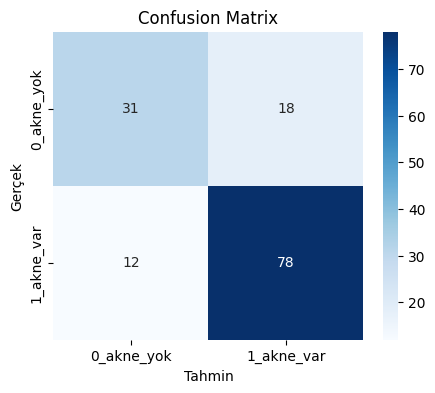

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from google.colab import files

# 1. Tahminleri Al
print("Test verisi üzerinde tahmin yapılıyor...")
y_true = []
for img, label in test_ds:
    y_true.extend(label.numpy().flatten())
y_true = np.array(y_true)

preds = model.predict(test_ds)
y_pred = (preds.flatten() > 0.5).astype(int) # Eşik değeri 0.5

# 2. Raporlar
print("\n--- SINIFLANDIRMA RAPORU ---")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n--- KARMAŞIKLIK MATRİSİ ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin'); plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf
from google.colab import files

# 1. Eğittiğin modeli kaydet (eğer kaydetmediysen)
model.save('my_acne_model.h5')
print(" Model .h5 olarak kaydedildi")

# 2. Yeniden yükle
loaded_model = tf.keras.models.load_model('my_acne_model.h5')
print(" Model yüklendi")

# 3. TFLite'a dönüştür (EN UYUMLU AYARLAR)
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

# ÖNEMLI: Hiçbir optimizasyon yapma!
converter.optimizations = []

# Standart TFLite operasyonları
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

# Dönüştür
print(" TFLite'a dönüştürülüyor...")
tflite_model = converter.convert()

# Kaydet
filename = 'acne_model_final.tflite'
with open(filename, 'wb') as f:
    f.write(tflite_model)

print(f" Model başarıyla dönüştürüldü: {filename}")
print(f" Dosya boyutu: {len(tflite_model) / 1024:.2f} KB")

# İndir
files.download(filename)
print("⬇ Model indiriliyor...")

 Model .h5 olarak kaydedildi


 Model yüklendi
 TFLite'a dönüştürülüyor...
Saved artifact at '/tmp/tmpmlsu64py'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134812003675664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134812003675856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134812003676048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134812003674512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134812003677008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134812003674896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134812003677392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134814665199440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134812003673552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134812003674704: TensorSpec(shape=(), d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇ Model indiriliyor...
